<a href="https://colab.research.google.com/github/brodyanderson/MATH-6020-Project/blob/main/BreastCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MATH 6020 Project: April 2026
#### Breast Cancer Analysis

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [ ]:
## https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original

In [4]:
url = 'https://raw.githubusercontent.com/brodyanderson/MATH-6020-Project/main/breast_cancer.csv'
breast_cancer = pd.read_csv(url)

# Exploratory Data Analysis

In [8]:
print(breast_cancer.shape)
print(breast_cancer.describe)
print(breast_cancer.dtypes)
print(breast_cancer.isnull().sum())

(683, 10)
<bound method NDFrame.describe of      Clump Thickness  Uniformity of Cell Size  Uniformity of Cell Shape  \
0                  5                        1                         1   
1                  5                        4                         4   
2                  3                        1                         1   
3                  6                        8                         8   
4                  4                        1                         1   
..               ...                      ...                       ...   
678                3                        1                         1   
679                2                        1                         1   
680                5                       10                        10   
681                4                        8                         6   
682                4                        8                         8   

     Marginal Adhesion  Single Epithelial Cell Size  Ba

In [9]:
print(breast_cancer['Class'].value_counts())
# 2 for benign
# 4 for malignant

Class
2    444
4    239
Name: count, dtype: int64


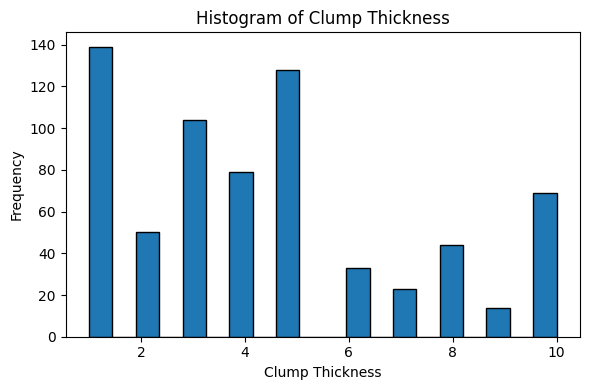

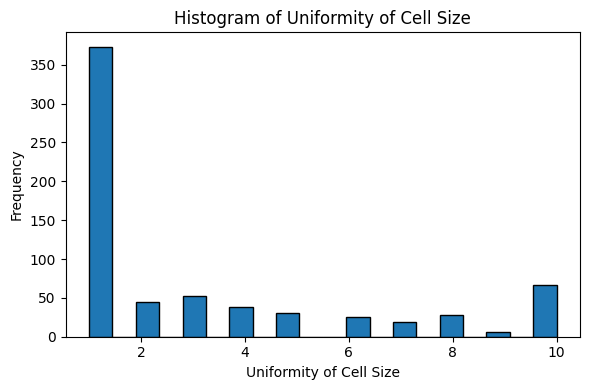

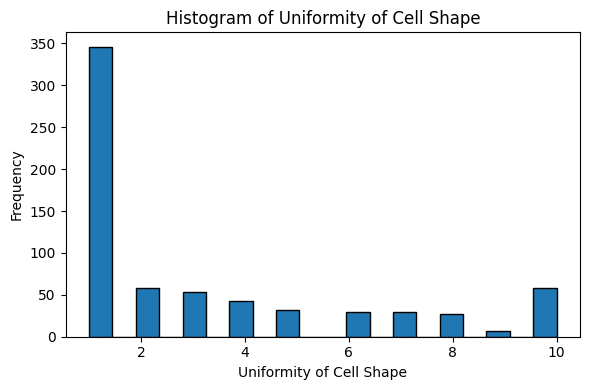

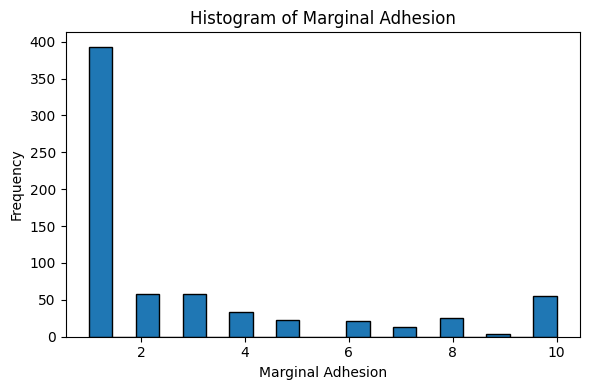

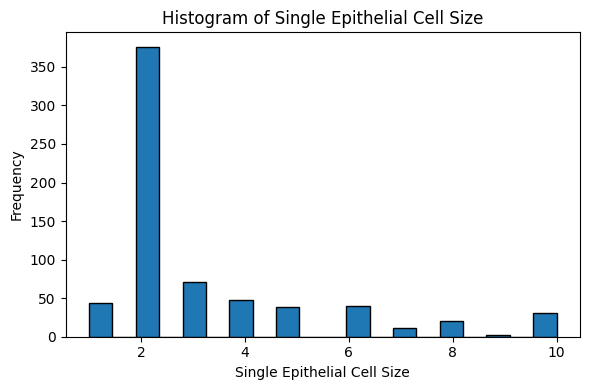

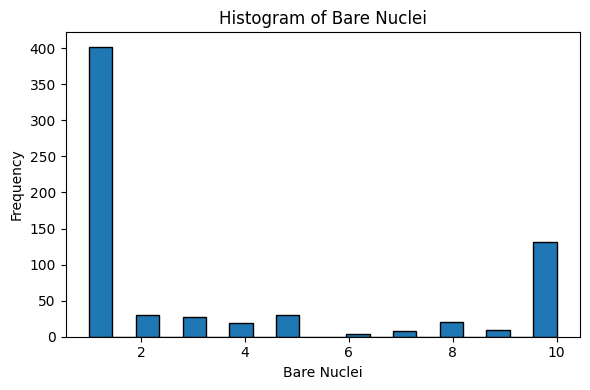

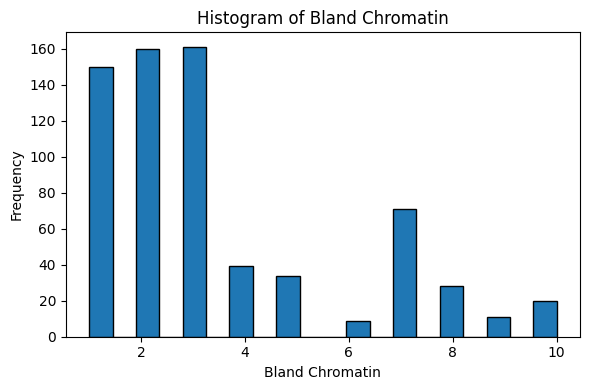

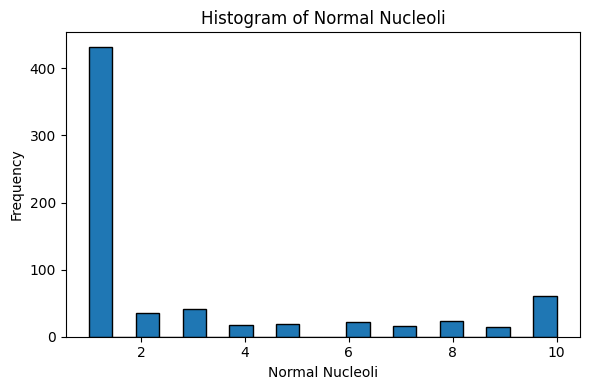

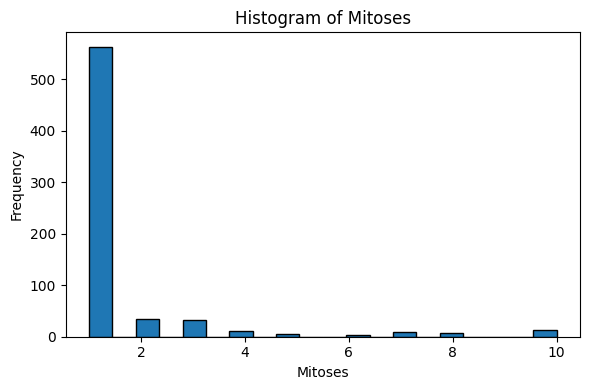

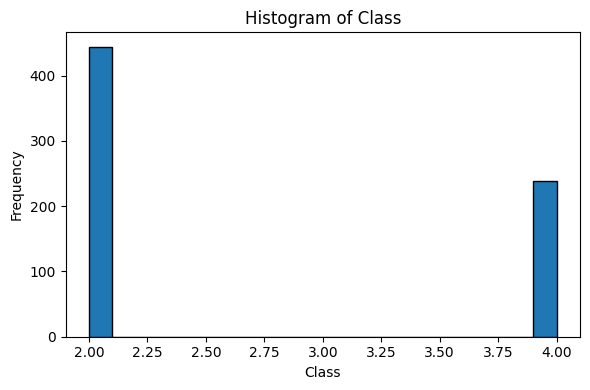

In [10]:
cols = breast_cancer.drop('Class', axis=1).columns

for col in breast_cancer.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(breast_cancer[col], bins=20, edgecolor='black')
    ax.set_title(f'Histogram of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

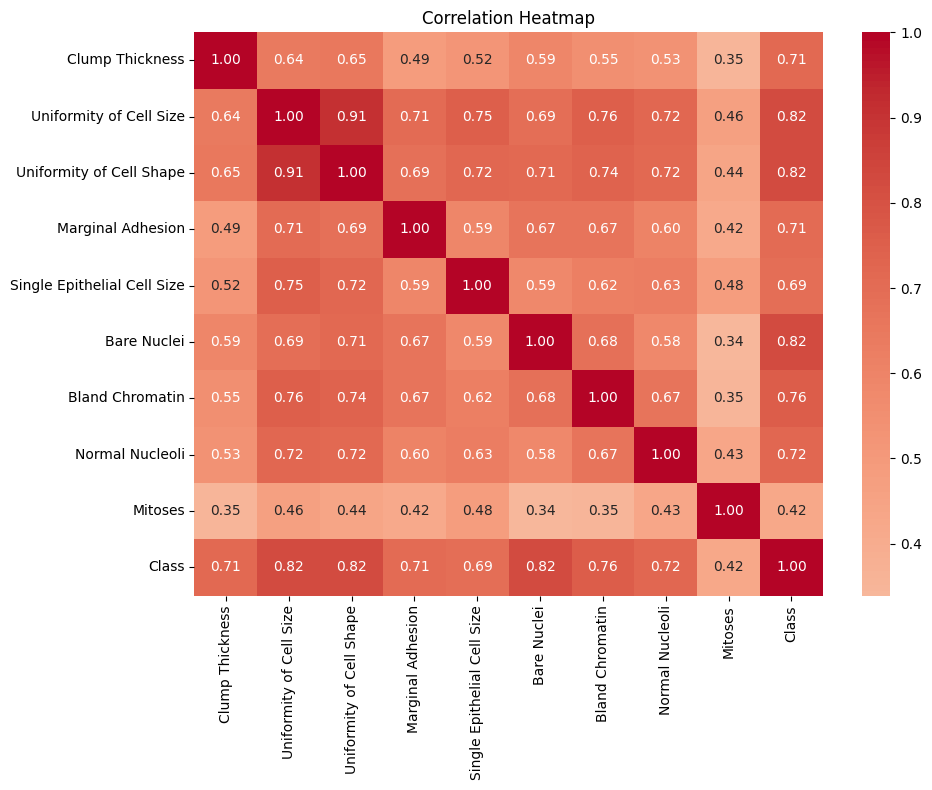

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(breast_cancer.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

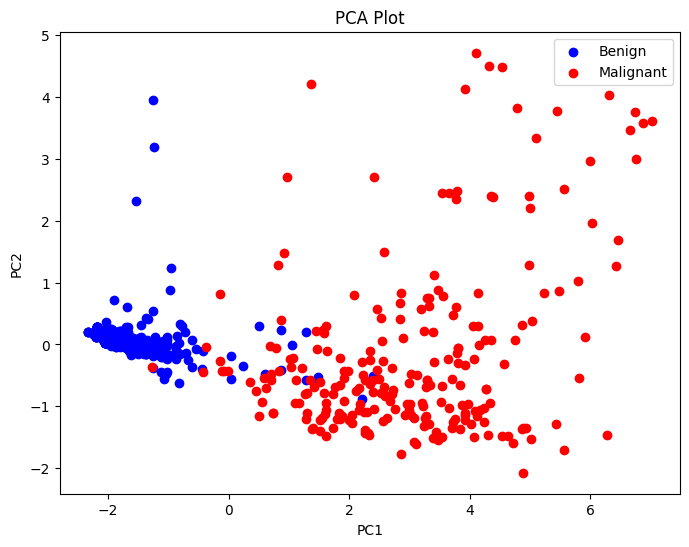

In [12]:
X = breast_cancer.drop('Class', axis=1)
y = breast_cancer['Class']

X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y == 2, 0], X_pca[y == 2, 1], label='Benign', color='blue')
plt.scatter(X_pca[y == 4, 0], X_pca[y == 4, 1], label='Malignant', color='red')
plt.title('PCA Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

In [20]:
pca1_var = pca.explained_variance_ratio_[0]
pca2_var = pca.explained_variance_ratio_[1]
pca_first_two_var = pca1_var + pca2_var

print(f"Percentage of variance explained by PC1: {pca1_var*100:.2f}%")
print(f"Percentage of variance explained by PC2: {pca2_var*100:.2f}%")
print(f"Percentage of varianced explained by PC1 & PC2: {pca_first_two_var*100:.2f}%")

Percentage of variance explained by PC1: 65.55%
Percentage of variance explained by PC2: 8.62%
Percentage of varianced explained by PC1 & PC2: 74.17%


# Train / Test Split

In [23]:
X = breast_cancer.drop('Class', axis=1).values
y = breast_cancer['Class'].map({2: 0, 4: 1}).values
# Now Benign=0 & Malignant=1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=399)

# Linear Discriminant Analysis

In [24]:
X_B = X_train[y_train == 0]  # Benign group
X_M = X_train[y_train == 1]  # Malignant group

X_bar_B = X_B.mean(axis=0)
X_bar_M = X_M.mean(axis=0)

N = len(y_train)
n_B = len(X_B)
n_M = len(X_M)
p = X_train.shape[1]

my_matrix = np.zeros((p, p))

for i in range(n_B):
    diff = X_B[i] - X_bar_B
    my_matrix = my_matrix + np.outer(diff, diff)

for i in range(n_M):
    diff = X_M[i] - X_bar_M
    my_matrix = my_matrix + np.outer(diff, diff)

Ehat = my_matrix / (N - 2)
print("Ehat:")
print(Ehat)

print("\nDiagonal of Ehat:")
print(np.diag(Ehat))

sqrt_diag = np.sqrt(np.diag(Ehat))

# Normalize each variable by within-group standard deviation (Train & Test)
X_train_norm = X_train / sqrt_diag
X_test_norm = X_test / sqrt_diag

Ehat:
[[ 3.97987627  0.40683382  0.51089315 -0.31373208  0.12191569  0.04803095
   0.10688931  0.17894906  0.17347974]
 [ 0.40683382  3.11119945  2.14795921  1.04294851  1.34983819 -0.0646365
   0.98535399  1.24300454  0.62590081]
 [ 0.51089315  2.14795921  3.0312353   0.86350505  1.13030695  0.23809481
   0.77117082  1.17771769  0.48443987]
 [-0.31373208  1.04294851  0.86350505  4.14919763  0.61812315  0.83157164
   1.04456461  0.83890396  0.67018939]
 [ 0.12191569  1.34983819  1.13030695  0.61812315  2.78508707  0.15264411
   0.59739837  1.05812342  0.76244809]
 [ 0.04803095 -0.0646365   0.23809481  0.83157164  0.15264411  4.46414445
   0.56752231 -0.06839265 -0.07631309]
 [ 0.10688931  0.98535399  0.77117082  1.04456461  0.59739837  0.56752231
   2.63569756  0.85825302  0.07931751]
 [ 0.17894906  1.24300454  1.17771769  0.83890396  1.05812342 -0.06839265
   0.85825302  4.74181925  0.82421961]
 [ 0.17347974  0.62590081  0.48443987  0.67018939  0.76244809 -0.07631309
   0.07931751  0.

# LDA on Training Data

In [29]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_norm, y_train)

lda_train_predictions = lda.predict(X_train_norm)

lda_confusion_matrix = pd.crosstab(y_train, lda_train_predictions, rownames=['Actual'], colnames=['Predicted'])
print(lda_confusion_matrix)

correct = sum(lda_train_predictions == y_train)
total = len(y_train)
accuracy = correct / total * 100

print(f"\nTraining percentage of data points predicted correctly:")
print(f"{accuracy:.2f}%")

Predicted    0    1
Actual             
0          345    7
1           16  178

Training percentage of data points predicted correctly:
95.79%


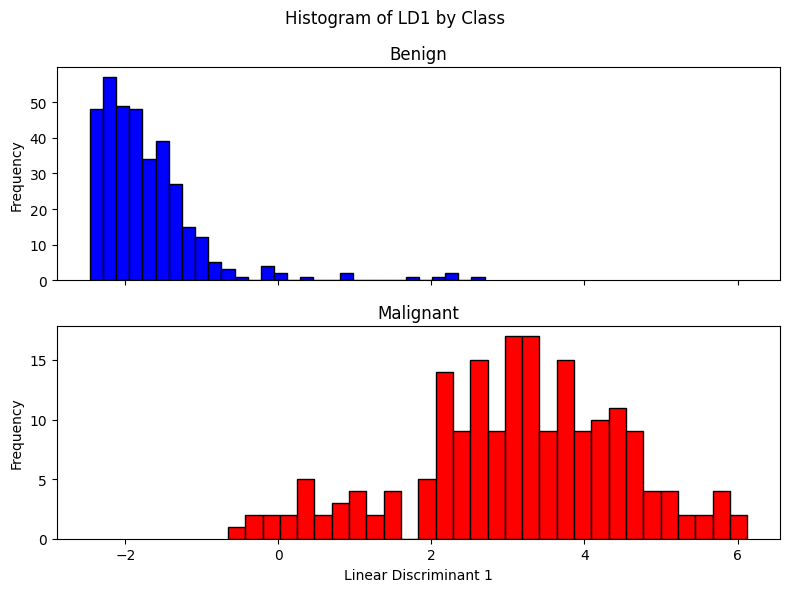

In [27]:
# LDA for graphing
LD1_train = lda.transform(X_train_norm).flatten()

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].hist(LD1_train[y_train == 0], bins=30, color='blue', edgecolor='black')
axes[0].set_title('Benign')
axes[0].set_ylabel('Frequency')

axes[1].hist(LD1_train[y_train == 1], bins=30, color='red', edgecolor='black')
axes[1].set_title('Malignant')
axes[1].set_ylabel('Frequency')

plt.suptitle('Histogram of LD1 by Class')
plt.xlabel('Linear Discriminant 1')
plt.tight_layout()
plt.show()

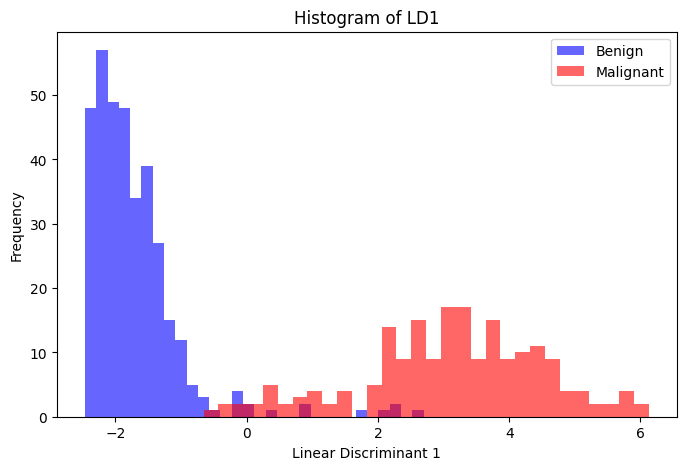

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(LD1_train[y_train == 0], bins=30, alpha=0.6, label='Benign', color='blue')
plt.hist(LD1_train[y_train == 1], bins=30, alpha=0.6, label='Malignant', color='red')
plt.title('Histogram of LD1')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# LDA on Test Data

In [30]:
lda_test_predictions = lda.predict(X_test_norm)

lda_test_confusion_matrix = pd.crosstab(y_test, lda_test_predictions, rownames=['Actual'], colnames=['Predicted'])
print(lda_test_confusion_matrix)

correct = sum(lda_test_predictions == y_test)
total = len(y_test)
accuracy = correct / total * 100

print(f"\nTesting percentage of data points predicted correctly:")
print(f"{accuracy:.2f}%")

Predicted   0   1
Actual           
0          91   1
1           2  43

Testing percentage of data points predicted correctly:
97.81%


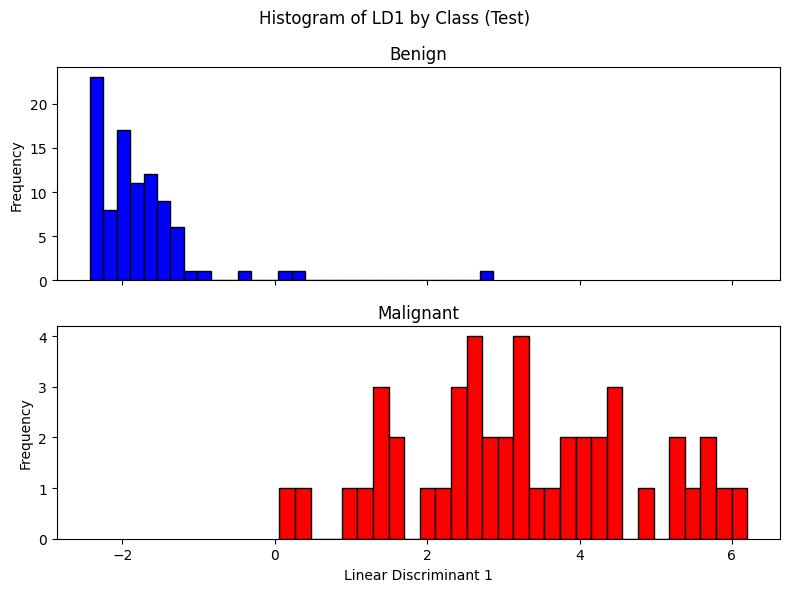

In [31]:
# LDA for graphing (Test)
LD1_test = lda.transform(X_test_norm).flatten()

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].hist(LD1_test[y_test == 0], bins=30, color='blue', edgecolor='black')
axes[0].set_title('Benign')
axes[0].set_ylabel('Frequency')

axes[1].hist(LD1_test[y_test == 1], bins=30, color='red', edgecolor='black')
axes[1].set_title('Malignant')
axes[1].set_ylabel('Frequency')

plt.suptitle('Histogram of LD1 by Class (Test)')
plt.xlabel('Linear Discriminant 1')
plt.tight_layout()
plt.show()

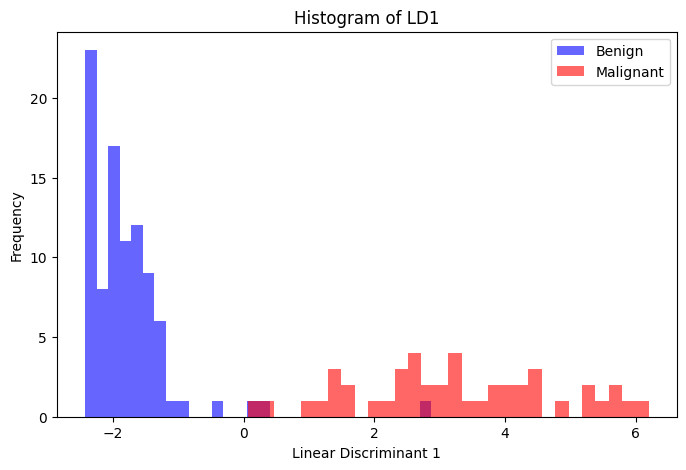

In [32]:
plt.figure(figsize=(8, 5))
plt.hist(LD1_test[y_test == 0], bins=30, alpha=0.6, label='Benign', color='blue')
plt.hist(LD1_test[y_test == 1], bins=30, alpha=0.6, label='Malignant', color='red')
plt.title('Histogram of LD1')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Logistic Regression w/ Cross Validation for Ridge

In [ ]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

logistic_regression = LogisticRegression(penalty='L2', random_state=28)
grid_search = GridSearchCV(logistic_regression, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_norm, y_train)